In [1]:
# ==========================================
# 1. Import Libraries
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


In [2]:

# ==========================================
# 2. Load Dataset as DataFrame
# ==========================================
housing = fetch_california_housing()

df = pd.DataFrame(housing.data, columns=housing.feature_names)
df["Price"] = housing.target

print("Dataset Shape:", df.shape)
print(df.head())



Dataset Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [3]:
# ==========================================
# 3. Feature-Target Split
# ==========================================
X = df.drop("Price", axis=1)
y = df["Price"]

# ==========================================
# 4. Train-Test Split
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==========================================
# 5. Feature Scaling (VERY IMPORTANT)
# ==========================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [4]:
# ==========================================
# 6. Build Multilayer Model
# ==========================================
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)  # Linear activation for regression
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()



C:\Users\HARSHAL CHELIKANI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │           1,152 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,521 (45.00 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ==========================================
# 7. Train Model
# ==========================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    verbose=1
)

# ==========================================
# 8. Evaluate Model
# ==========================================
loss, mae = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

print("Actual vs Predicted")
plt.show()

Epoch 1/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 0.7623 - mae: 0.5704 - val_loss: 0.4325 - val_mae: 0.4682
Epoch 2/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3648 - mae: 0.4291 - val_loss: 0.3940 - val_mae: 0.4345
Epoch 3/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.3408 - mae: 0.4104 - val_loss: 0.3551 - val_mae: 0.4281
Epoch 4/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3235 - mae: 0.3981 - val_loss: 0.3531 - val_mae: 0.4079
Epoch 5/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.3120 - mae: 0.3900 - val_loss: 0.3506 - val_mae: 0.4101
Epoch 6/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3001 - mae: 0.3794 - val_loss: 0.3346 - val_mae: 0.4068
Epoch 7/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.3085 - mae: 0.3782 - val_loss: 0.3238 - val_mae: 0.4026
Epoch 8/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.2938 - mae: 0.3707 - val_loss: 0.3254 - val_mae: 0.3886
Epoch 9/100
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 7

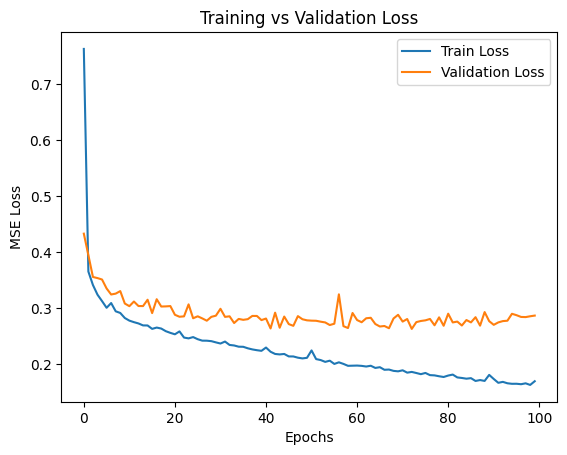

Text(0.5, 1.0, 'Actual vs Predicted')

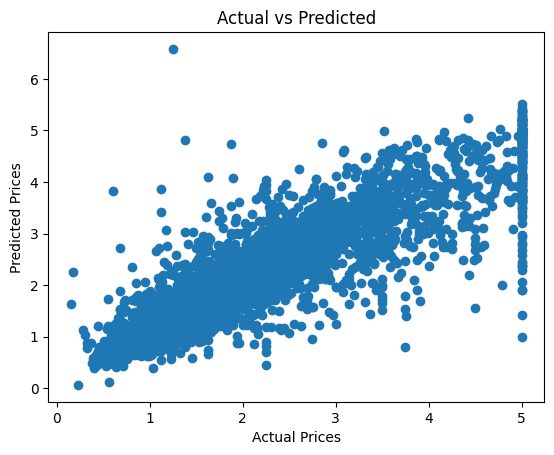

In [8]:
# ==========================================
# 9. Plot Training Curve
# ==========================================
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# ==========================================
# 10. Actual vs Predicted Plot
# ==========================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted")

In [9]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


In [10]:
# for batch 64
history_64 = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=64,
    verbose=0
)

In [11]:
test_loss_64, test_acc_64 = model.evaluate(X_test, y_test, verbose=0)

In [12]:
# for batch 128
history_128 = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=128,
    verbose=0
)

In [13]:
test_loss_128, test_acc_128 = model.evaluate(X_test, y_test, verbose=0)

In [14]:
print(history.history.keys())

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])


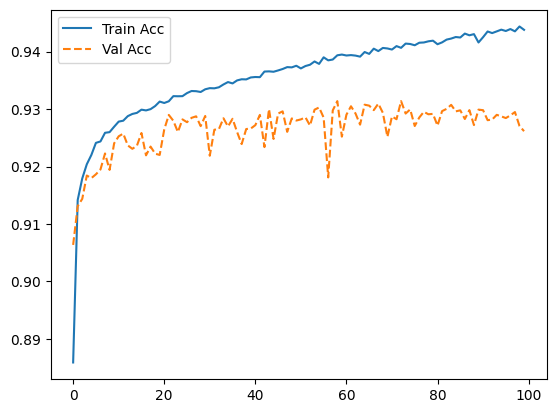

In [15]:
max_val = np.max(y_train)

train_acc_like = 1 - (np.array(history.history['mae']) / max_val)
val_acc_like = 1 - (np.array(history.history['val_mae']) / max_val)

plt.plot(train_acc_like, '-', label='Train Acc')
plt.plot(val_acc_like, '--', label='Val Acc')
plt.legend()
plt.show()

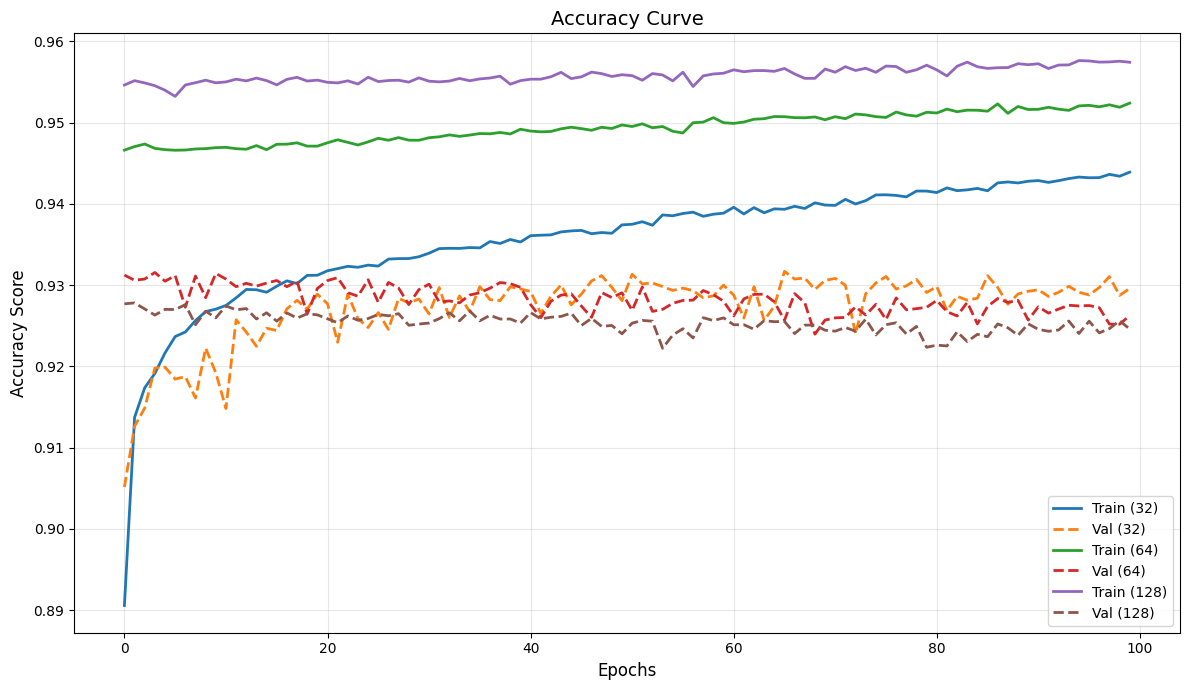

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

max_val = np.max(y_train)

# Convert MAE to accuracy-like
train_32 = 1 - (np.array(history.history['mae']) / max_val)
val_32   = 1 - (np.array(history.history['val_mae']) / max_val)

train_64 = 1 - (np.array(history_64.history['mae']) / max_val)
val_64   = 1 - (np.array(history_64.history['val_mae']) / max_val)

train_128 = 1 - (np.array(history_128.history['mae']) / max_val)
val_128   = 1 - (np.array(history_128.history['val_mae']) / max_val)


plt.figure(figsize=(12,7))

# Batch 32
plt.plot(train_32, '-',  linewidth=2, label='Train (32)')
plt.plot(val_32,   '--', linewidth=2, label='Val (32)')

# Batch 64
plt.plot(train_64, '-',  linewidth=2, label='Train (64)')
plt.plot(val_64,   '--', linewidth=2, label='Val (64)')

# Batch 128
plt.plot(train_128, '-',  linewidth=2, label='Train (128)')
plt.plot(val_128,   '--', linewidth=2, label='Val (128)')


plt.title("Accuracy Curve", fontsize=14)
plt.xlabel("Epochs", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()